# Decision Tree Classifier from Scratch

Decision trees make predictions by working down a tree of yes/no questions about the features, continuing until an end point is reached that leads to a label.

In this notebook, we'll:
1. Learn how decision trees choose the best split points
2. Understand Gini Impurity as a measure of class purity
3. Build a decision tree manually using the Iris dataset

Let's start by loading the Iris dataset, which contains measurements of three species of iris flowers:

In [16]:
# Get Iris as dataframe
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
target_names = iris.target_names
df['target'] = [target_names[i] for i in iris.target]
print(f'Species Distribution:\n{df["target"].value_counts()}\n')
df.head()

Species Distribution:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Branches of a Decision Tree are created by splitting the data across feature values using thresholds that create more homogenous splits. To find those thresholds, we need a way to measure how mixed the data is.

**Gini Impurity** is one such measure, computed by subtracting from one the squared proportion of each class. A value of 0 means all items belong to the same class, while a value close to 1 means the data is evenly distributed across many classes.

The Iris data is evenly split across three classes:

1 - (1/3^2 + 1/3^2 + 1/3^2) = 1 - (1/9 + 1/9 + 1/9) = 1 - 1/3 = 2/3

In [17]:
def gini_impurity(x):
    prob_sq_sum = sum((count / len(x)) ** 2 for count in x.value_counts())
    return 1 - prob_sq_sum

print(f"Dataset Gini Impurity: {gini_impurity(df['target']):.4f}")

Dataset Gini Impurity: 0.6667


Let's take a look at the distributions of features and the relationships between them to see if we can spot which we can use to most cleanly separate classes:

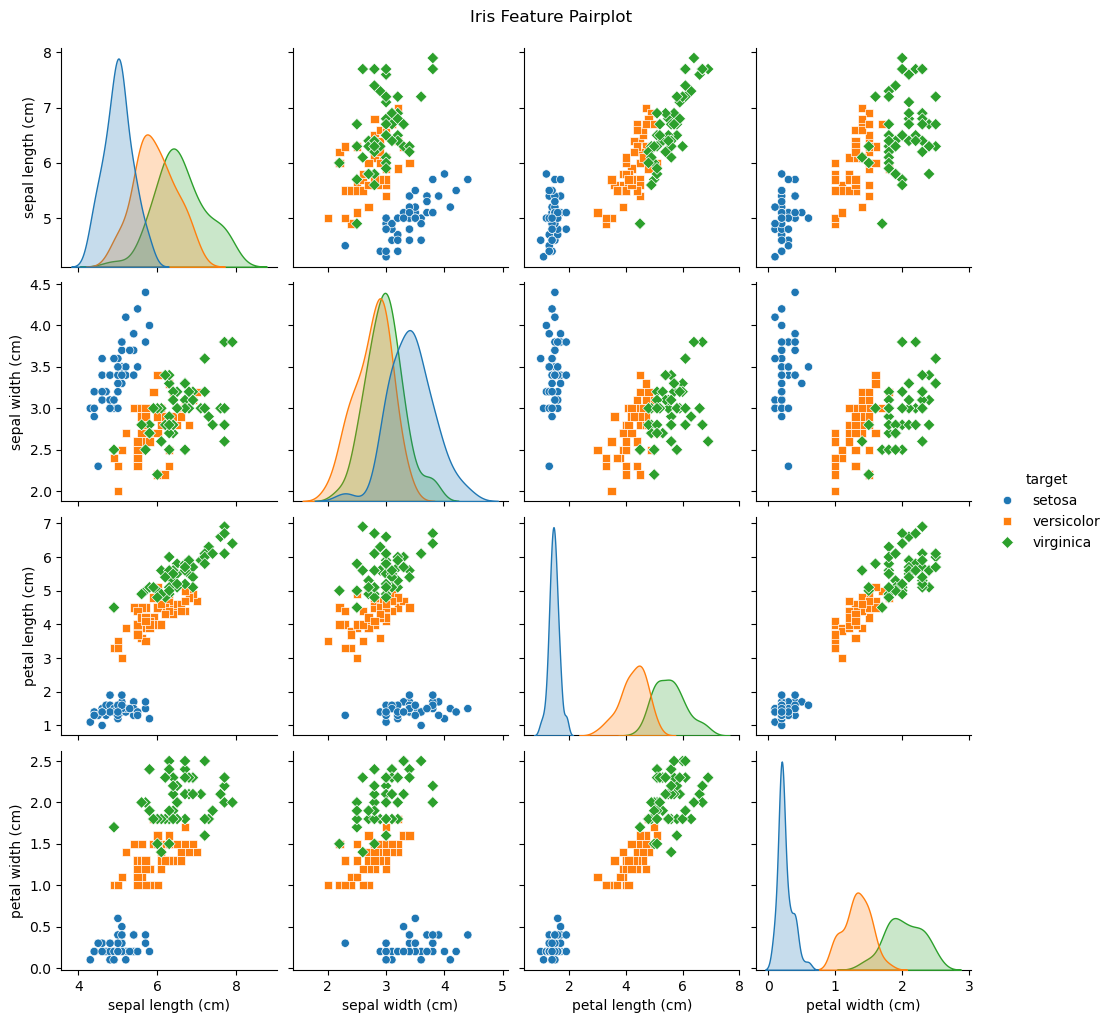

In [18]:
# Visualize feature ranges by species
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df, hue='target', markers=['o', 's', 'D'])
plt.suptitle('Iris Feature Pairplot', y=1.02)
plt.show()

In [30]:
df.groupby('target').agg(['min','max']).T

target                 setosa  versicolor  virginica
sepal length (cm) min     4.3         4.9        4.9
                  max     5.8         7.0        7.9
sepal width (cm)  min     2.3         2.0        2.2
                  max     4.4         3.4        3.8
petal length (cm) min     1.0         3.0        4.5
                  max     1.9         5.1        6.9
petal width (cm)  min     0.1         1.0        1.4
                  max     0.6         1.8        2.5

It's easy to see that setosa is cleanly split from the other classes by both petal length and petal width. Let's see Gini Impurity after splitting both features by the half-way point between setosa's max value and the versicolor's min value:

In [20]:
# Split by petal length at 2.45 cm (half-way between setosa max = 1.9 and versicolor min = 3.0)
pl_split_value = 2.45
pl_left_split = df[df['petal length (cm)'] <= pl_split_value]
pl_right_split = df[df['petal length (cm)'] > pl_split_value]
pl_left_impurity = gini_impurity(pl_left_split['target'])
pl_right_impurity = gini_impurity(pl_right_split['target'])
print(f'Left Split Gini Impurity: {pl_left_impurity:.4f} (pure setosa)')
print(f'Right Split Gini Impurity: {pl_right_impurity:.4f} (half versicolor, half virginica)')
print(f'Weighted Gini Impurity After Split: {((len(pl_left_split) * pl_left_impurity) + (len(pl_right_split) * pl_right_impurity)) / len(df):.4f}')

Left Split Gini Impurity: 0.0000 (pure setosa)
Right Split Gini Impurity: 0.5000 (half versicolor, half virginica)
Weighted Gini Impurity After Split: 0.3333


In [21]:
# split by petal width at 0.8 cm (half-way between setosa max = 0.6 and versicolor min = 1.0)
pw_split_value = 0.8
pw_left_split = df[df['petal width (cm)'] <= pw_split_value]
pw_right_split = df[df['petal width (cm)'] > pw_split_value]
pw_left_impurity = gini_impurity(pw_left_split['target'])
pw_right_impurity = gini_impurity(pw_right_split['target'])
print(f'Left Split Gini Impurity: {pw_left_impurity:.4f} (pure setosa)')
print(f'Right Split Gini Impurity: {pw_right_impurity:.4f} (half versicolor, half virginica)')
print(f'Weighted Gini Impurity After Split: {((len(pw_left_split) * pw_left_impurity) + (len(pw_right_split) * pw_right_impurity)) / len(df):.4f}')

Left Split Gini Impurity: 0.0000 (pure setosa)
Right Split Gini Impurity: 0.5000 (half versicolor, half virginica)
Weighted Gini Impurity After Split: 0.3333


Now let's use scikit-learn's DecisionTreeClassifier to train a full tree and test a prediction. For a point with petal length of 1.0 cm (which is ≤ 2.45), we expect it to be classified as setosa.


In [22]:
# Test classification of petal length left split
from sklearn.tree import DecisionTreeClassifier
import numpy as np

X = iris.data
y = iris.target

# Create and train the decision tree classifier
clf = DecisionTreeClassifier(random_state=2025)
clf.fit(X, y)

# Test with a point having petal length of 1.0
test_point = np.array([[5.0, 3.0, 1.0, 0.2]])

# Make prediction
prediction = clf.predict(test_point)
prediction_proba = clf.predict_proba(test_point)

print(f"Predicted class name: {iris.target_names[prediction[0]]}")

Predicted class name: setosa


After the first split, the right side (petal length > 2.45) still contains both versicolor and virginica. Let's visualize this subset to see how we can further separate these two classes.


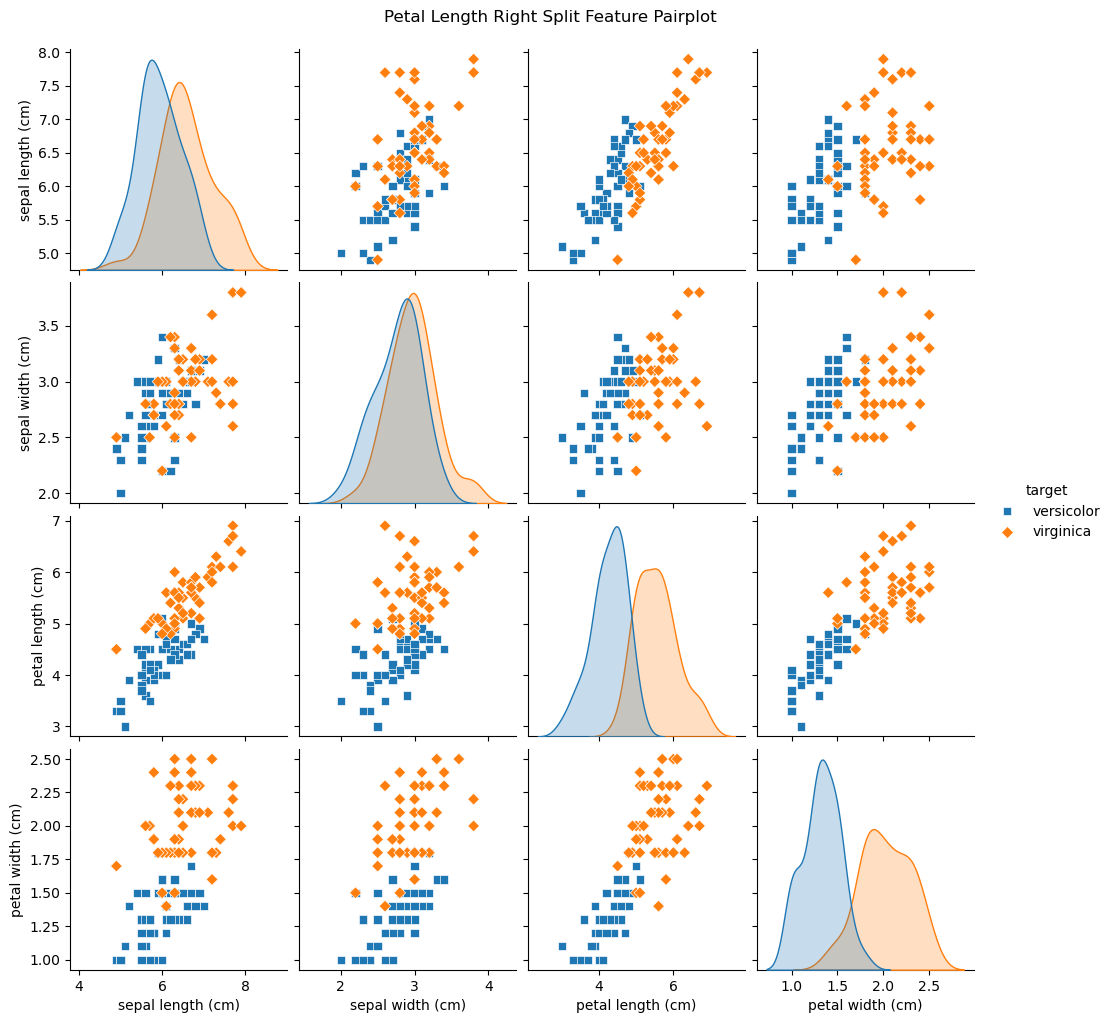

In [23]:
sns.pairplot(pl_right_split, hue='target', markers=['s', 'D'])
plt.suptitle('Petal Length Right Split Feature Pairplot', y=1.02)
plt.show()

Just eyeballing it, the remaining classes seem most separated by petal width, though they look well-separated by petal length as well. To find the optimal second split, we'll iterate through all possible petal width values and calculate the weighted Gini impurity for each potential split point. The split that minimizes this value is chosen.


Optimal Petal Width Split at: 1.75 cm with Gini Impurity: 0.1103

Left Split Species Distribution:
target
versicolor    49
virginica      5
Name: count, dtype: int64

Right Split Species Distribution:
target
virginica     45
versicolor     1
Name: count, dtype: int64



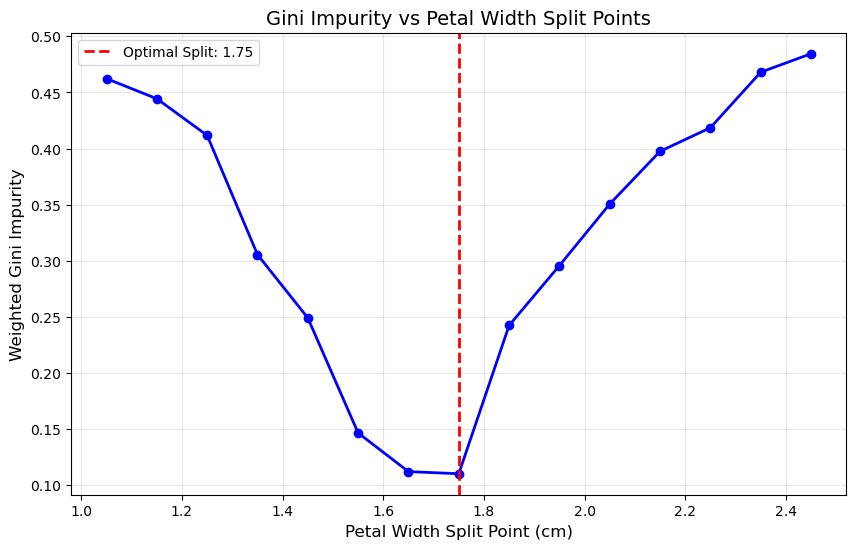

In [32]:
# Sort petal widths and corresponding targets
sorted_pw = pl_right_split.sort_values(by='petal width (cm)')
petal_lengths = sorted_pw['petal width (cm)'].values
targets = sorted_pw['target'].values

gini_values = []
split_points = []
best_gini = float('inf')
best_split = None

# Iterate through possible split points
for i in range(1, len(petal_widths)):
    if petal_widths[i] != petal_widths[i - 1]:
        pw_split_value = (petal_widths[i] + petal_widths[i - 1]) / 2
        split_points.append(pw_split_value)
        
        pw_left_split = sorted_pw[sorted_pw['petal width (cm)'] <= pw_split_value]
        pw_right_split = sorted_pw[sorted_pw['petal width (cm)'] > pw_split_value]
        left_impurity = gini_impurity(pw_left_split['target'])
        right_impurity = gini_impurity(pw_right_split['target'])
        weighted_gini = ((len(pw_left_split) * left_impurity) + (len(pw_right_split) * right_impurity)) / len(pl_right_split)
        gini_values.append(weighted_gini)
        
        if weighted_gini < best_gini:
            best_gini = weighted_gini
            best_split = pw_split_value

print(f'Optimal Petal Width Split at: {best_split:.2f} cm with Gini Impurity: {best_gini:.4f}\n')

# Class distributions by splits
pw_left_split_dist = sorted_pw[sorted_pw['petal width (cm)'] <= best_split].target.value_counts()
pw_right_split_dist = sorted_pw[sorted_pw['petal width (cm)'] > best_split].target.value_counts()

print(f'Left Split Species Distribution:\n{pw_left_split_dist}\n')
print(f'Right Split Species Distribution:\n{pw_right_split_dist}\n')

# Plot weighted Gini impurity across split points
plt.figure(figsize=(10, 6))
plt.plot(split_points, gini_values, 'b-o', linewidth=2, markersize=6)
plt.axvline(x=best_split, color='r', linestyle='--', linewidth=2, label=f'Optimal Split: {best_split:.2f}')
plt.xlabel('Petal Width Split Point (cm)', fontsize=12)
plt.ylabel('Weighted Gini Impurity', fontsize=12)
plt.title('Gini Impurity vs Petal Width Split Points', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Let's confirm that petal width was the right choice by finding the optimal split across petal length and its corresponding Gini impurity. If it's higher than 0.1103, we'll stick with petal width.

In [25]:
# Sort petal lengths and corresponding targets
sorted_pl = pl_right_split.sort_values(by='petal length (cm)')
petal_lengths = sorted_pw['petal length (cm)'].values
targets = sorted_pw['target'].values

# Initialize variables to track best split
best_gini = float('inf')
best_split = None

# Iterate through possible split points
for i in range(1, len(petal_lengths)):
    if petal_lengths[i] != petal_lengths[i - 1]:
        pw_split_value = (petal_lengths[i] + petal_lengths[i - 1]) / 2
        
        pw_left_split = sorted_pw[sorted_pw['petal length (cm)'] <= pw_split_value]
        pw_right_split = sorted_pw[sorted_pw['petal length (cm)'] > pw_split_value]
        left_impurity = gini_impurity(pw_left_split['target'])
        right_impurity = gini_impurity(pw_right_split['target'])
        weighted_gini = ((len(pw_left_split) * left_impurity) + (len(pw_right_split) * right_impurity)) / len(pl_right_split)
        
        if weighted_gini < best_gini:
            best_gini = weighted_gini
            best_split = pw_split_value

print(f'Optimal Petal Width Split at: {best_split:.2f} cm with Gini Impurity: {best_gini:.4f}\n')

Optimal Petal Width Split at: 4.70 cm with Gini Impurity: 0.1265



Petal width was indeed the right choice! Now let's test predictions based on our knowledge of these first couple of split points. A point with petal length > 2.45 and petal width > 1.75 should be classified as virginica.


In [26]:
# Test with a point having petal length > 2.45, petal width > 1.75
test_point = np.array([[5.0, 3.0, 3.0, 2.0]])

# Make prediction
prediction = clf.predict(test_point)
prediction_proba = clf.predict_proba(test_point)

print(f"Predicted class name: {iris.target_names[prediction[0]]}")

Predicted class name: virginica


Similarly, a point with petal length > 2.45 but petal width ≤ 1.75 should be classified as versicolor.


In [27]:
# Test with a point having petal length > 2.45, petal width < 1.75
test_point = np.array([[5.0, 3.0, 3.0, 1.0]])

# Make prediction
prediction = clf.predict(test_point)
prediction_proba = clf.predict_proba(test_point)

print(f"Predicted class name: {iris.target_names[prediction[0]]}")

Predicted class name: versicolor


Here's a visual representation of the decision tree we've built:

```
                         [root]
               petal length ≤ 2.45?
                    /            \
                 yes              no
              (setosa)        petal width ≤ 1.75?
                                  /            \
                               yes              no
                         (versicolor)        (virginica)
```

So what did we learn?

1. **Use Gini Impurity to Find the Best Splits:** Lower Gini impurity means a more homogeneous set of classes. Decision tree algorithms build trees by finding splits that minimize Gini impurity.

2. **Recursive Splits Lead to Purer Leaves and Higher-Confidence Predictions:** Each split aims to create child nodes that are more pure (have lower Gini impurity) than their parent, eventually leading to leaf nodes where one class dominates. The dominant class will be the prediction!
